### LOGISTIC REGRESSION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, recall_score, accuracy_score, precision_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

#### 1. Data Exploration:
- a. Load the dataset and perform exploratory data analysis (EDA).

In [2]:
df = pd.read_csv("diabetes.csv")
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [3]:
df.shape

(768, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


- b. Examine the features, their types, and summary statistics.

In [6]:
stats = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Mode': df.mode().iloc[0],
    'Q1': df.quantile(0.25),
    'Q2': df.quantile(0.50),
    'Q3': df.quantile(0.75),
    'IQR': df.quantile(0.75) - df.quantile(0.25),
    'Min': df.min(),
    'Max' : df.max()
})
stats

,Mean,Median,Mode,Q1,Q2,Q3,IQR,Min,Max
Pregnancies,3.845052,3.0000,1.000,1.00000,3.0000,6.00000,5.0000,0.000,17.00
Glucose,120.894531,117.0000,99.000,99.00000,117.0000,140.25000,41.2500,0.000,199.00
BloodPressure,69.105469,72.0000,70.000,62.00000,72.0000,80.00000,18.0000,0.000,122.00
SkinThickness,20.536458,23.0000,0.000,0.00000,23.0000,32.00000,32.0000,0.000,99.00
Insulin,79.799479,30.5000,0.000,0.00000,30.5000,127.25000,127.2500,0.000,846.00
BMI,31.992578,32.0000,32.000,27.30000,32.0000,36.60000,9.3000,0.000,67.10
DiabetesPedigreeFunction,0.471876,0.3725,0.254,0.24375,0.3725,0.62625,0.3825,0.078,2.42
Age,33.240885,29.0000,22.000,24.00000,29.0000,41.00000,17.0000,21.000,81.00
Outcome,0.348958,0.0000,0.000,0.00000,0.0000,1.00000,1.0000,0.000,1.00


- The summary statistics show the central tendency and spread of the variables. Some features, especially Insulin, have a large difference between their mean and median and contain extreme values.

- c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.

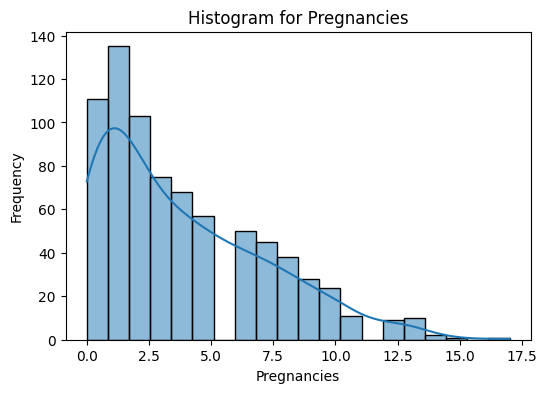

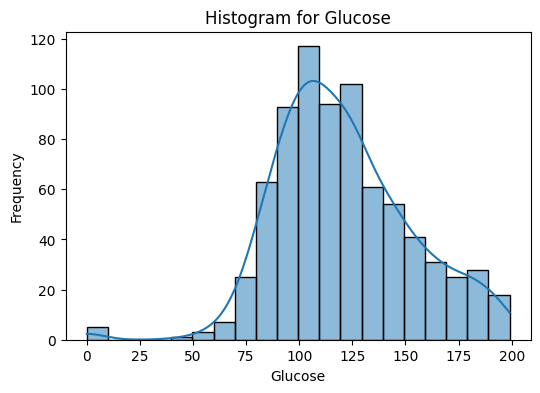

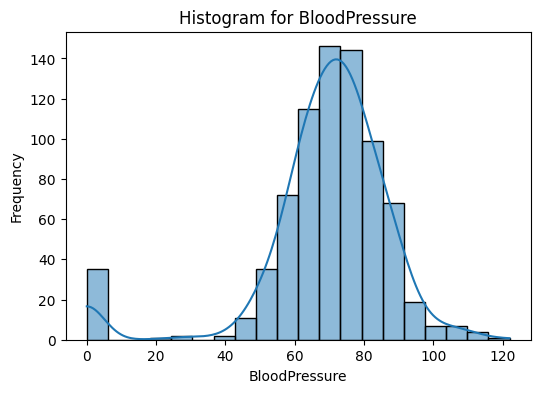

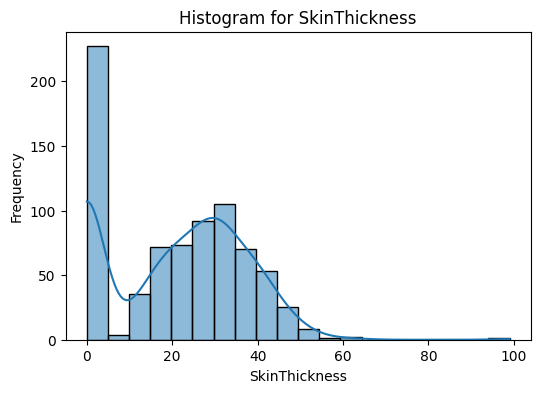

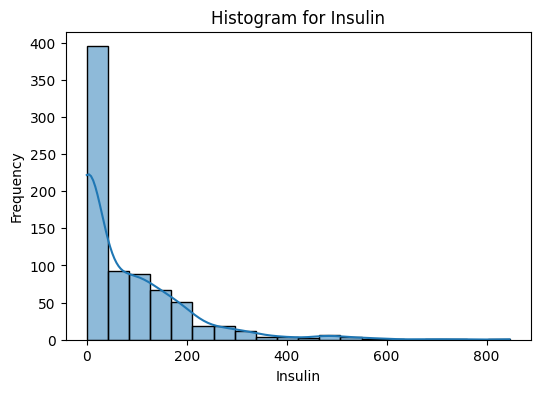

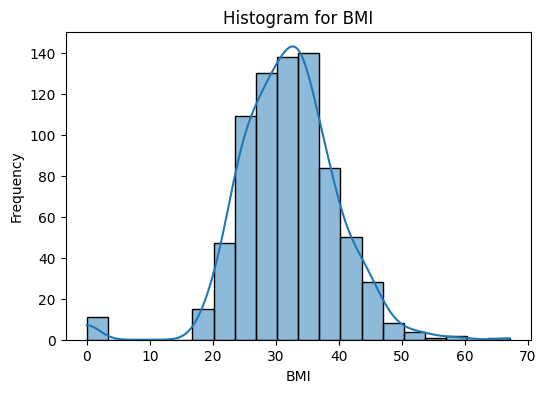

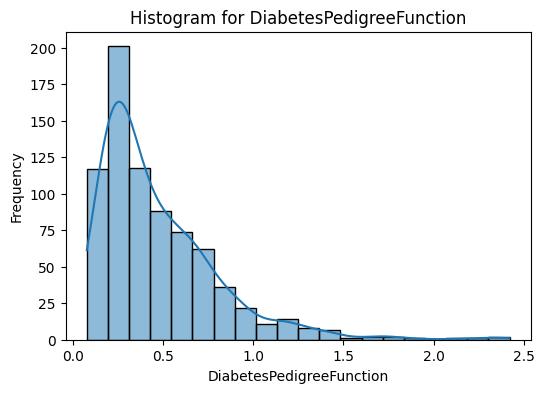

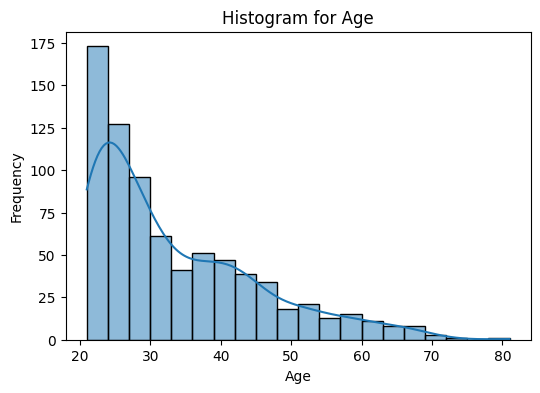

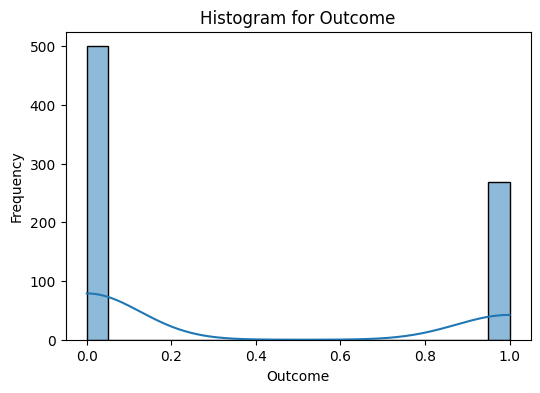

In [7]:
for col in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f"Histogram for {col}")
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

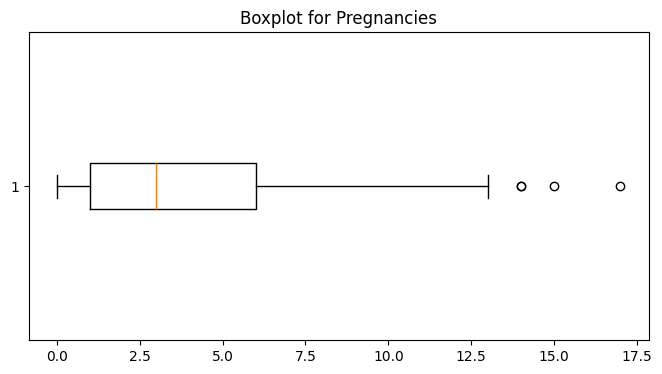

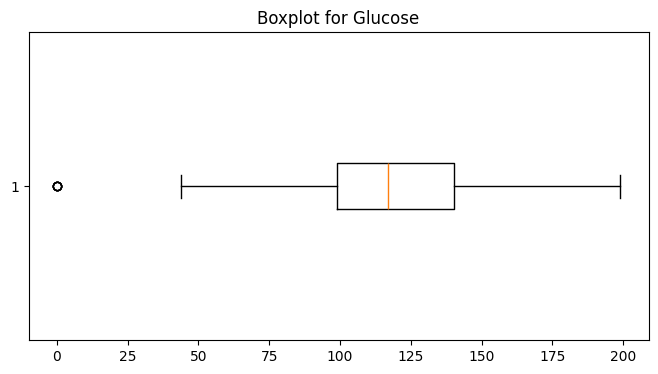

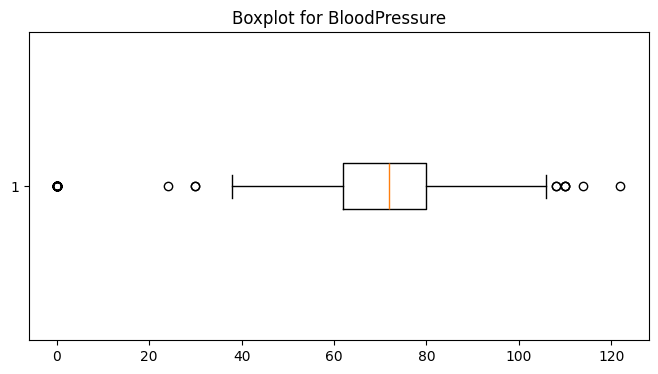

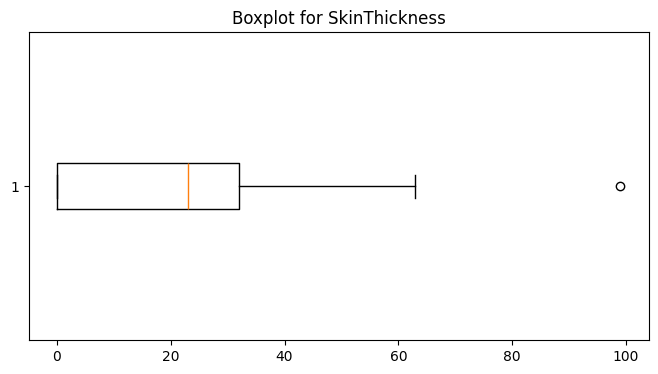

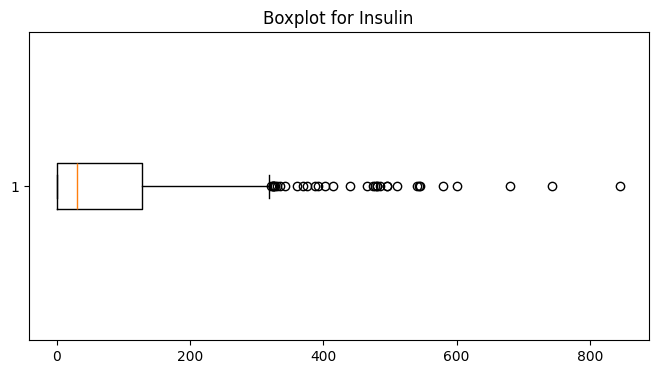

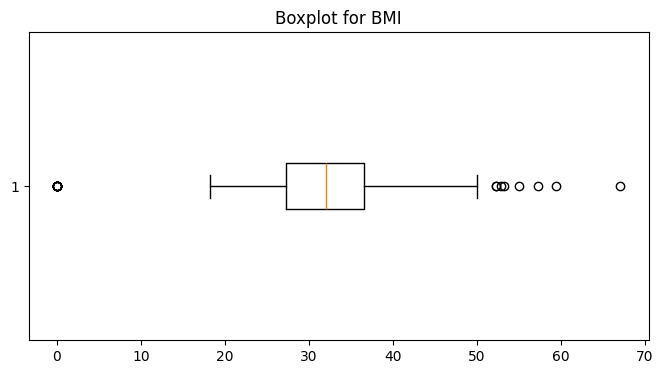

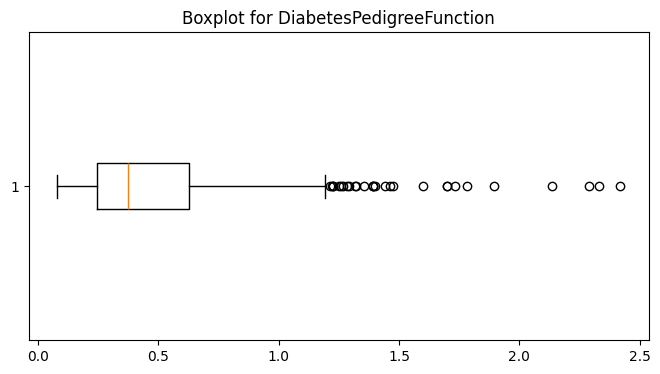

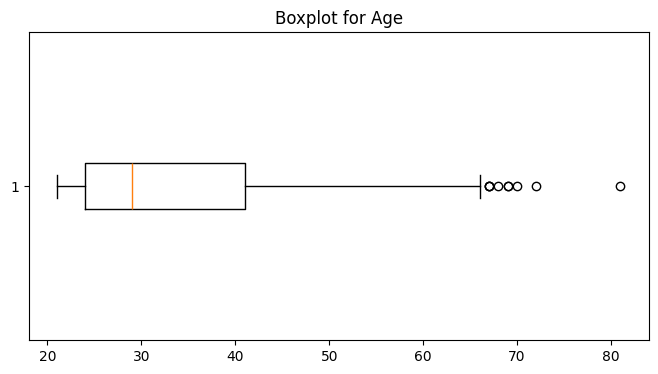

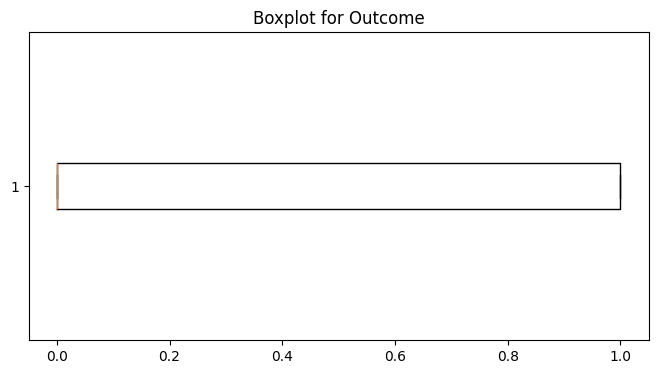

In [8]:
for col in df.columns:
    plt.figure(figsize=(8,4))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot for {col}")
    plt.show()

<Figure size 1200x1200 with 0 Axes>

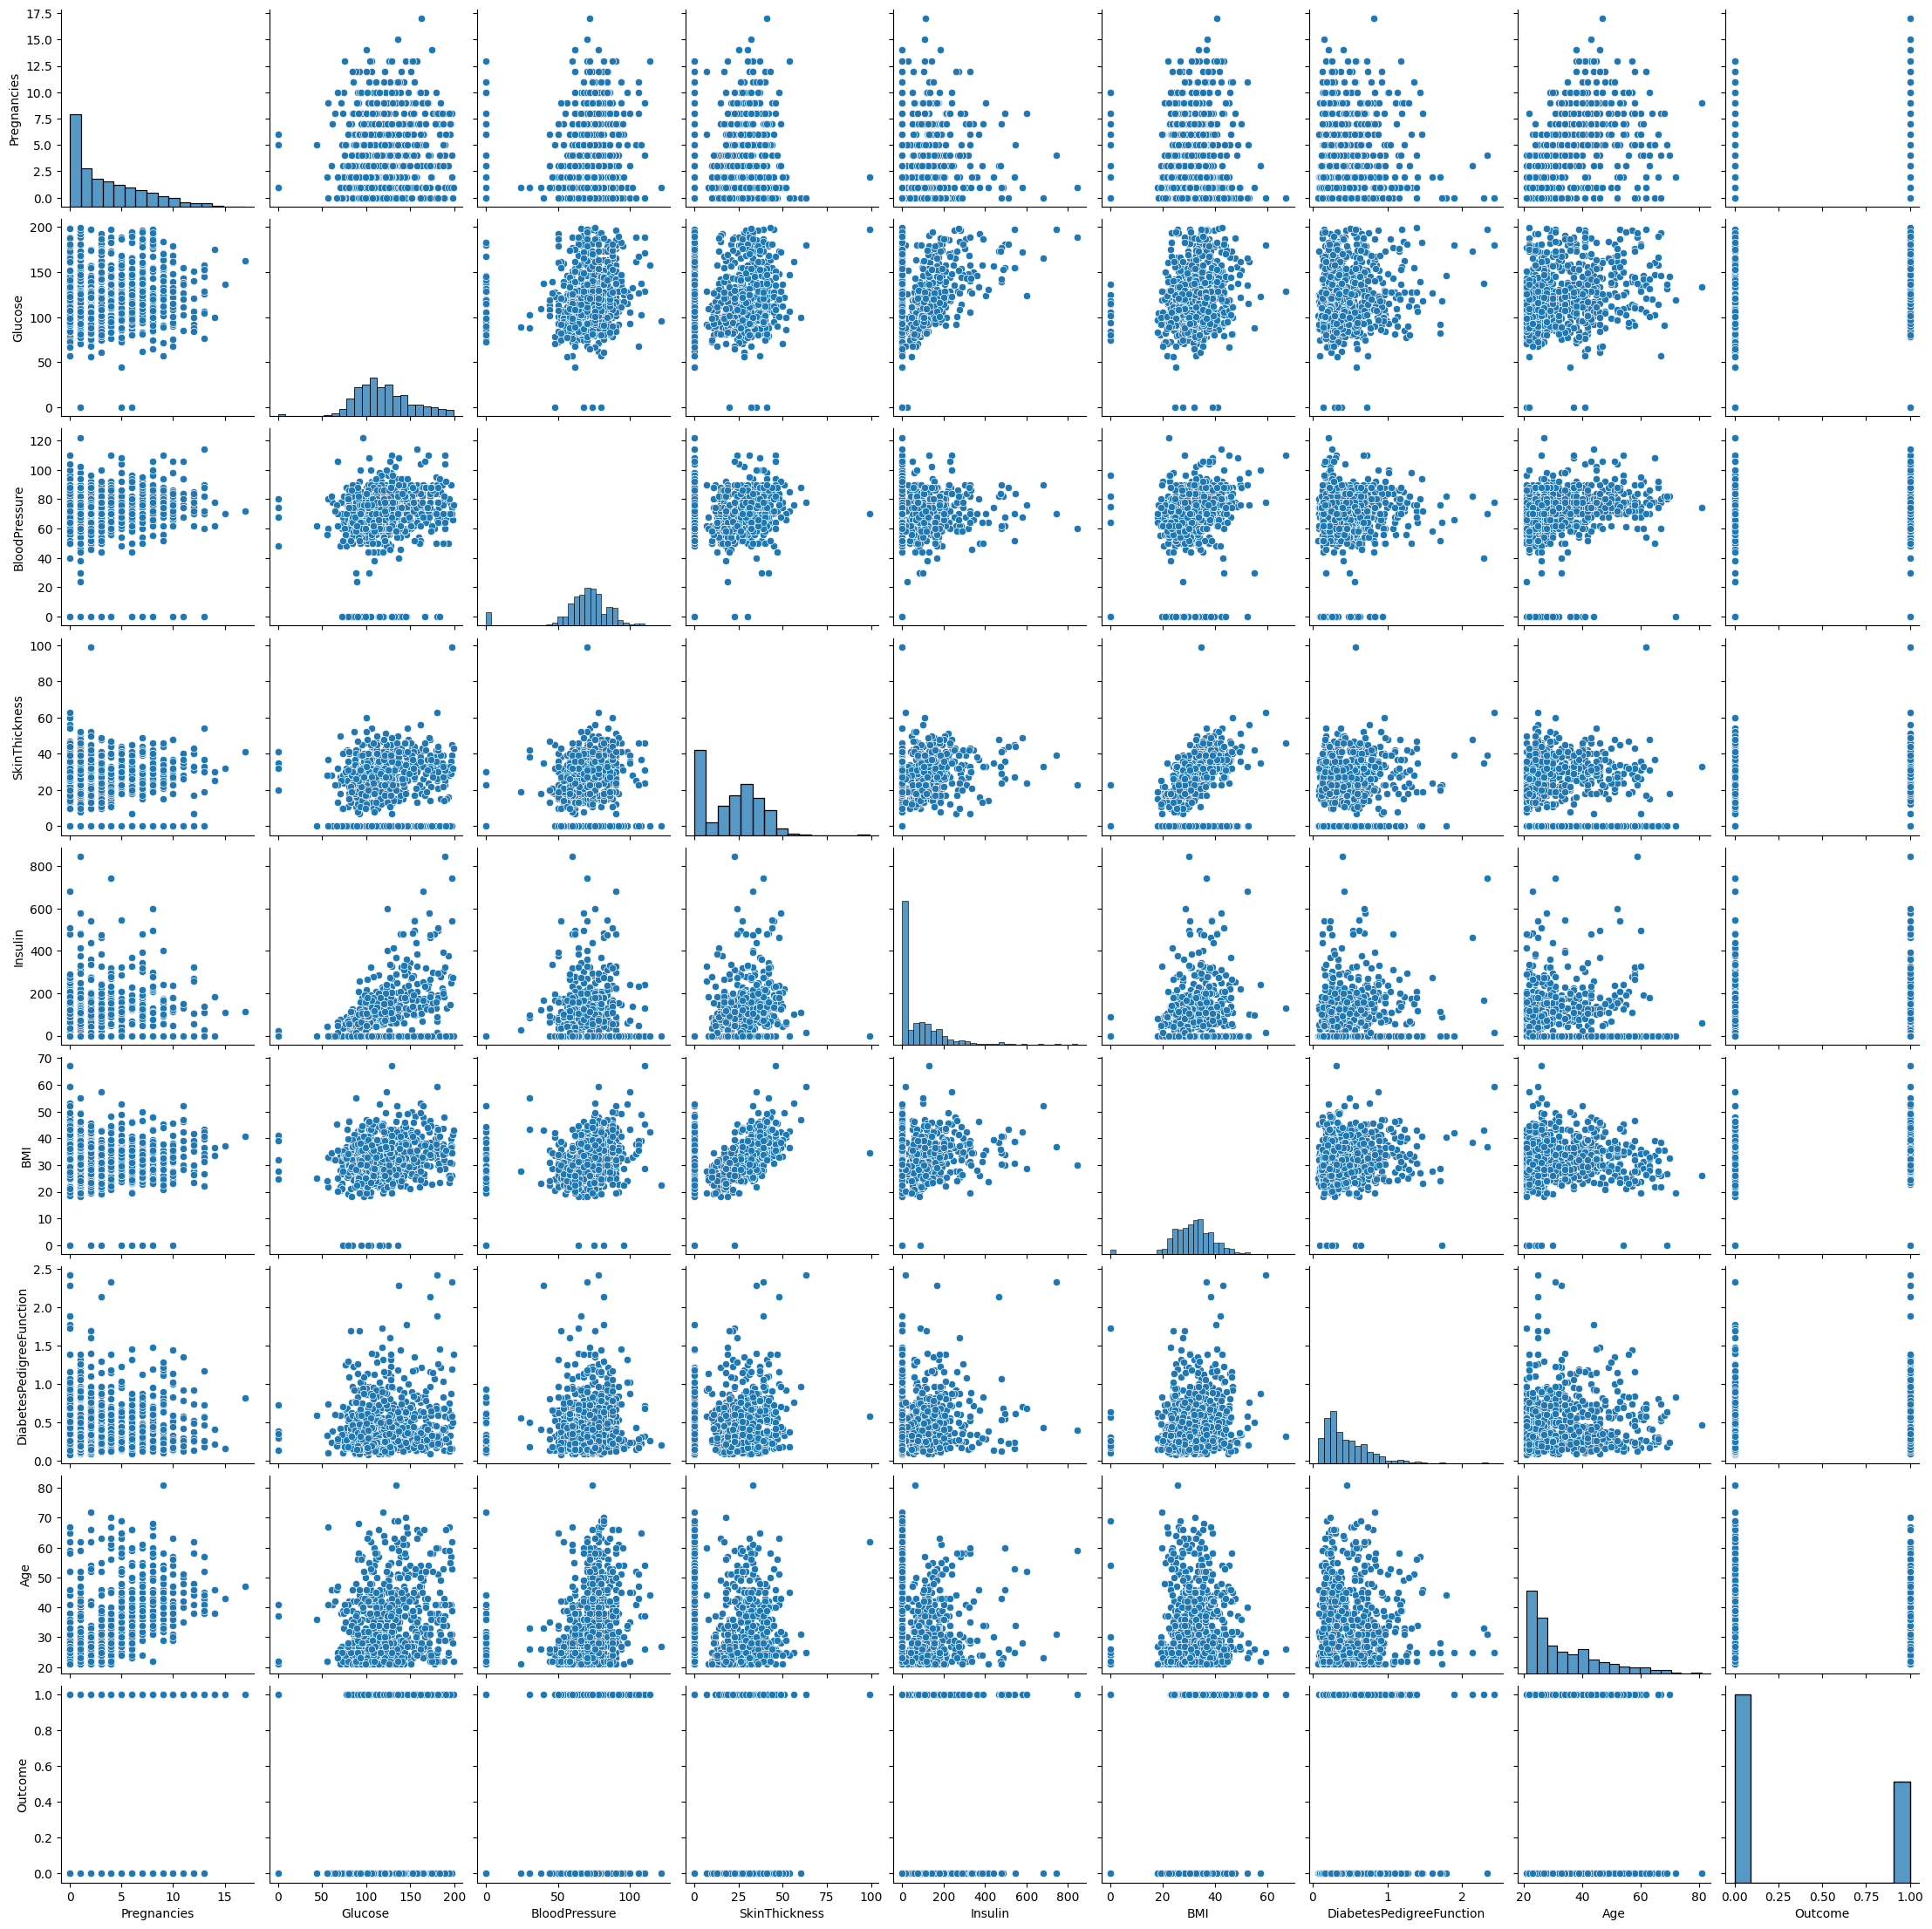

<Figure size 1200x1200 with 0 Axes>

In [9]:
sns.pairplot(df)
plt.figure(figsize=(12,12))

### 2. Data Preprocessing:
- a. Handle missing values (e.g., imputation).
- b. Encode categorical variables. - all the values are in int and float so encoding categorical variables are not nessasry
- Although the dataset had no actual null values, some medical features contained zero values, which are not realistic measurements. For example, a BMI or glucose value of zero is not a valid measurement.

- After examining the distributions, mean imputation was used for Glucose and BloodPressure because their distributions are relatively symmetric. Median imputation was used for SkinThickness, Insulin, and BMI because they have more skewness and/or outliers. After imputation, there were no missing values.

In [10]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in df[cols]:
    print(col,(df[col]==0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [11]:
df[cols] = df[cols].replace(0,np.nan)

In [12]:
df['Glucose'].fillna(df['Glucose'].mean(), inplace=True)
df['BloodPressure'].fillna(df['BloodPressure'].mean(), inplace=True)
df['SkinThickness'].fillna(df['SkinThickness'].median(), inplace=True)
df['Insulin'].fillna(df['Insulin'].median(), inplace=True)
df['BMI'].fillna(df['BMI'].median(), inplace=True)

In [13]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.000000,6.00000,17.00
Glucose,768.0,121.686763,30.435949,44.000,99.75000,117.000000,140.25000,199.00
BloodPressure,768.0,72.405184,12.096346,24.000,64.00000,72.202592,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.000000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.000000,127.25000,846.00
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.300000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.372500,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.000000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.000000,1.00000,1.00


In [15]:
stst1 = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Mode': df.mode().iloc[0],
    'Q1': df.quantile(0.25),
    'Q2': df.quantile(0.50),
    'Q3': df.quantile(0.75),
    'IQR': df.quantile(0.75)-df.quantile(0.25),
    'Min': df.min(),
    'Max': df.max()
})

stst1

,Mean,Median,Mode,Q1,Q2,Q3,IQR,Min,Max
Pregnancies,3.845052,3.000000,1.000,1.00000,3.000000,6.00000,5.0000,0.000,17.00
Glucose,121.686763,117.000000,99.000,99.75000,117.000000,140.25000,40.5000,44.000,199.00
BloodPressure,72.405184,72.202592,70.000,64.00000,72.202592,80.00000,16.0000,24.000,122.00
SkinThickness,29.108073,29.000000,29.000,25.00000,29.000000,32.00000,7.0000,7.000,99.00
Insulin,140.671875,125.000000,125.000,121.50000,125.000000,127.25000,5.7500,14.000,846.00
BMI,32.455208,32.300000,32.300,27.50000,32.300000,36.60000,9.1000,18.200,67.10
DiabetesPedigreeFunction,0.471876,0.372500,0.254,0.24375,0.372500,0.62625,0.3825,0.078,2.42
Age,33.240885,29.000000,22.000,24.00000,29.000000,41.00000,17.0000,21.000,81.00
Outcome,0.348958,0.000000,0.000,0.00000,0.000000,1.00000,1.0000,0.000,1.00


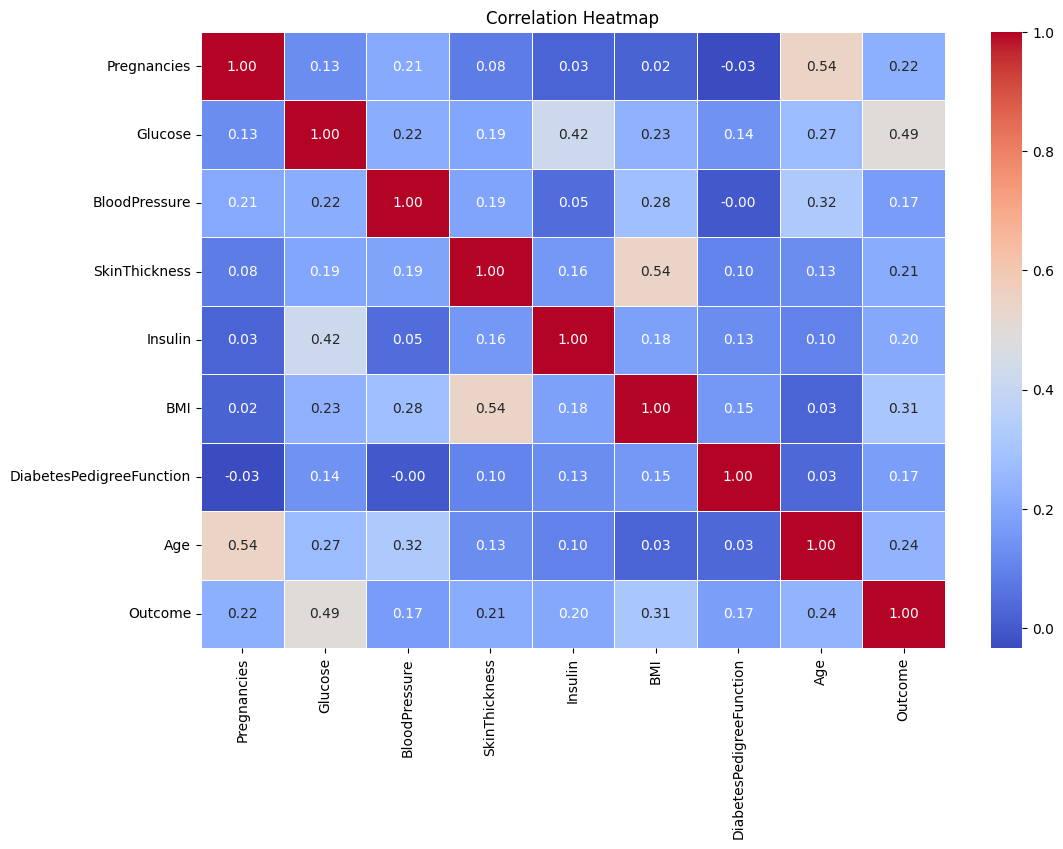

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap = 'coolwarm',
    linewidths = 0.5
)
plt.title("Correlation Heatmap")
plt.show()

- The strongest relationships with Outcome were:

- Glucose = 0.49
- BMI = 0.31
- Age = 0.24
- Pregnancies = 0.22

Glucose has the strongest positive correlation with diabetes outcome, suggesting that higher glucose levels are more strongly associated with diabetes in this dataset.

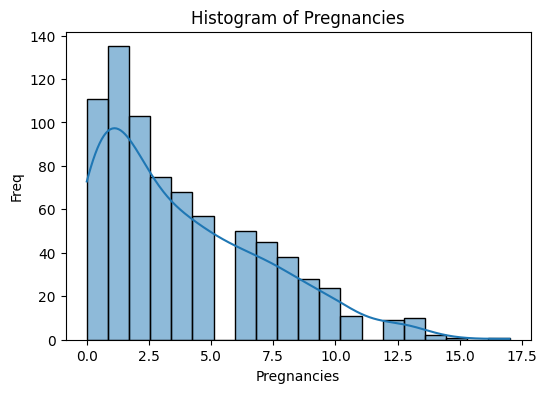

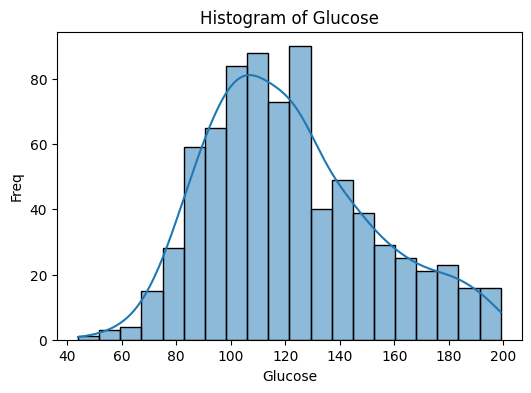

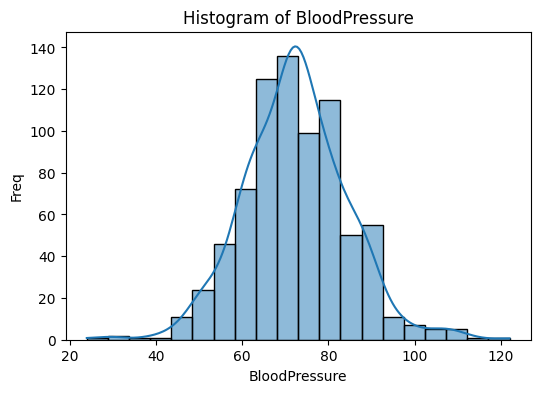

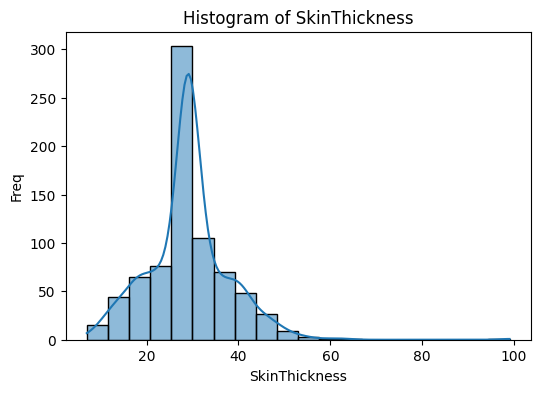

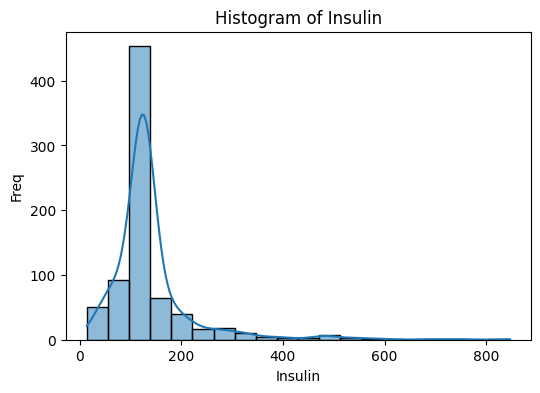

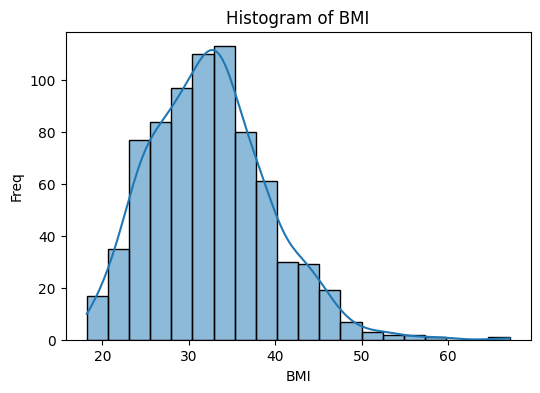

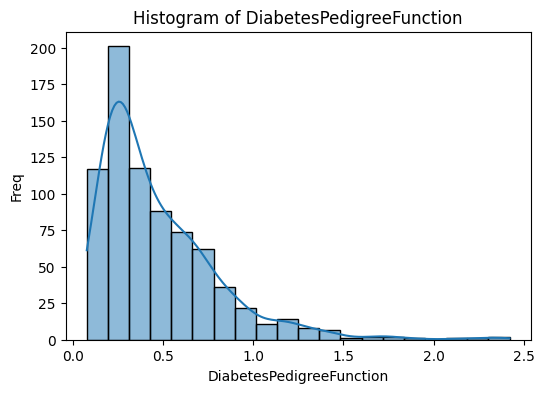

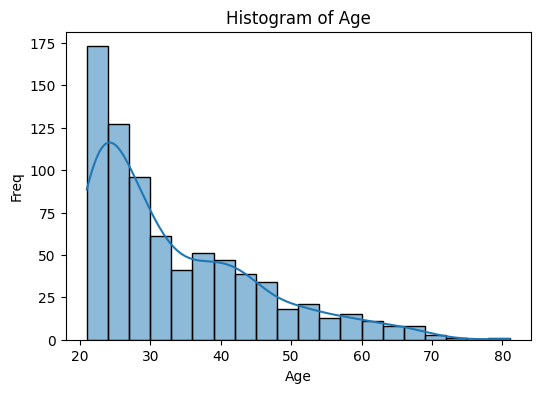

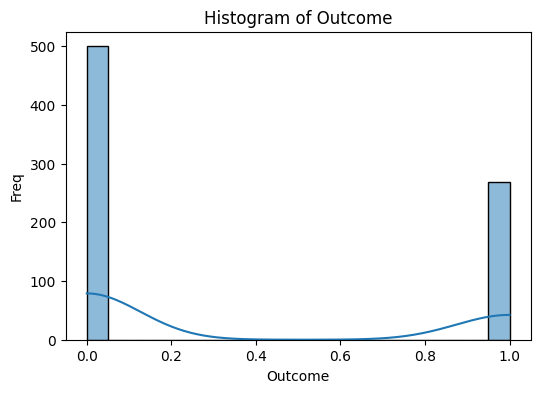

In [17]:
for col in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Freq")
    plt.show()

- Histograms were used to understand the distribution of each feature. Pregnancies, Insulin, DiabetesPedigreeFunction, and Age are right-skewed. Glucose is approximately bell-shaped with a slight right skew, while BloodPressure is relatively symmetric. BMI is also slightly right-skewed.

- The Outcome histogram shows that there are more non-diabetic patients than diabetic patients.

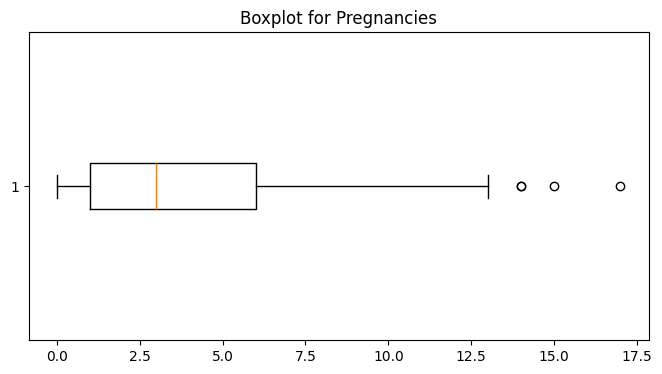

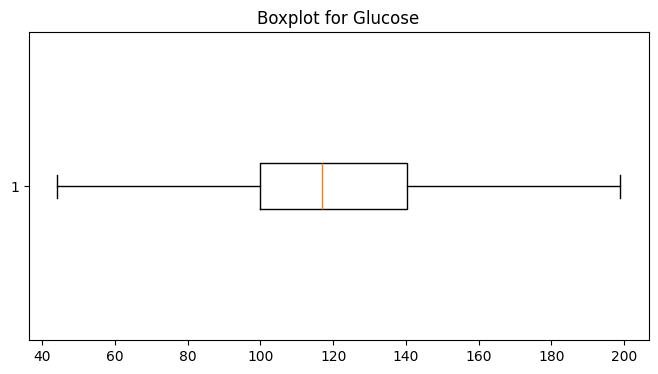

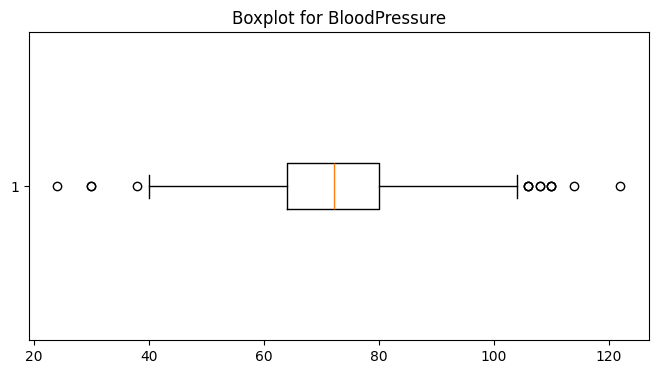

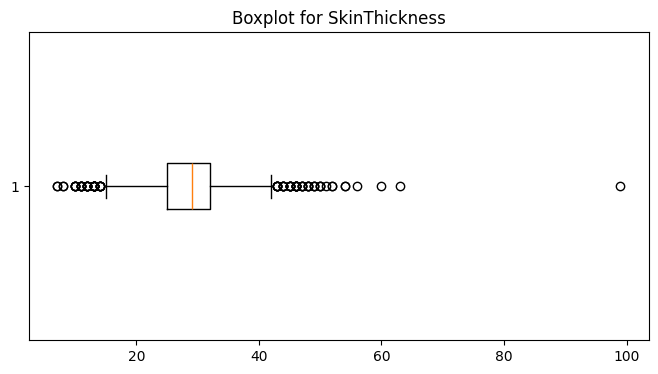

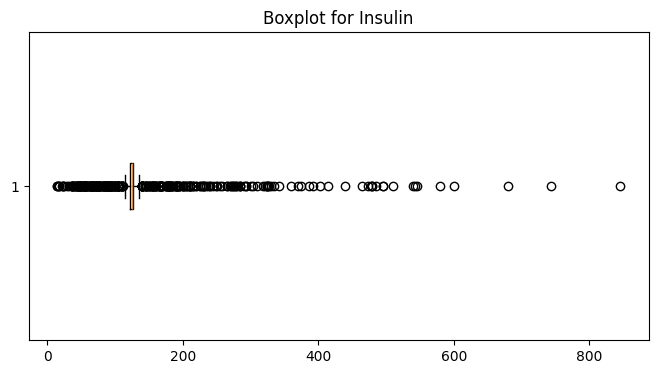

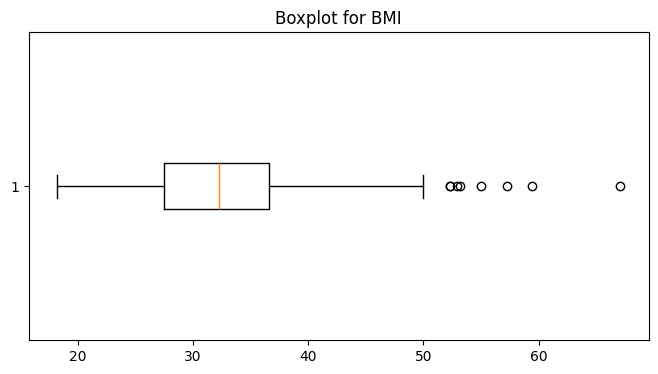

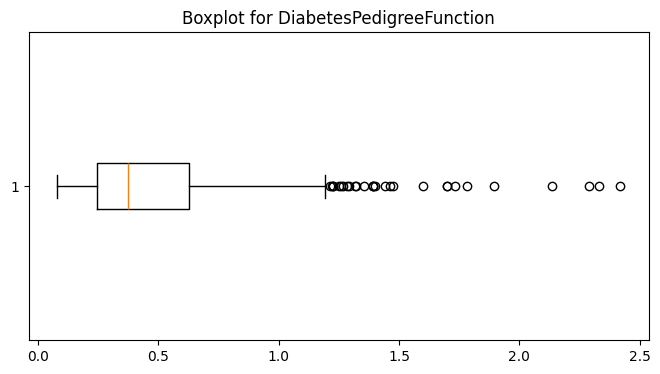

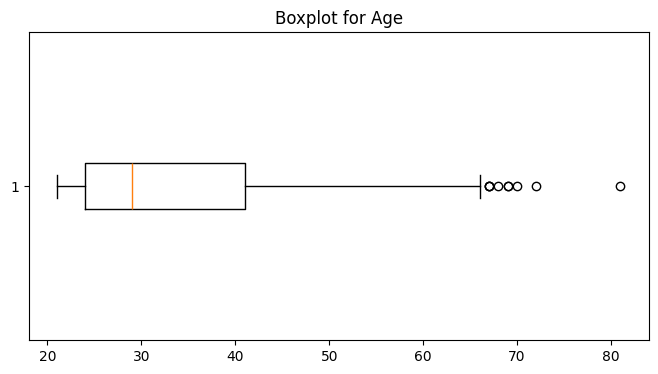

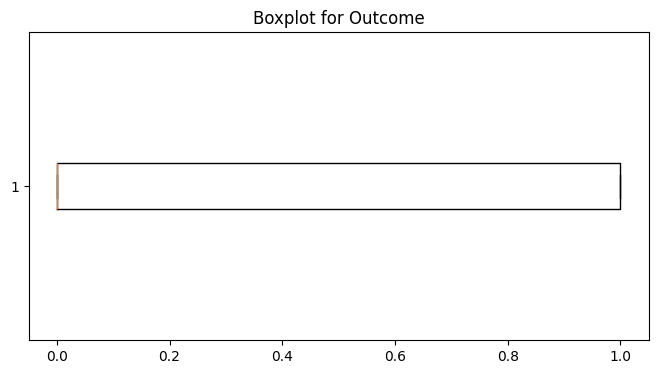

In [19]:
for col in df.columns:
    plt.figure(figsize=(8,4))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot for {col}")
    plt.show()

- Box plots were used to identify outliers. Insulin has many extreme outliers, while SkinThickness, BMI, Age, and DiabetesPedigreeFunction also contain some outliers. These outliers are important when deciding how to handle missing or invalid values.

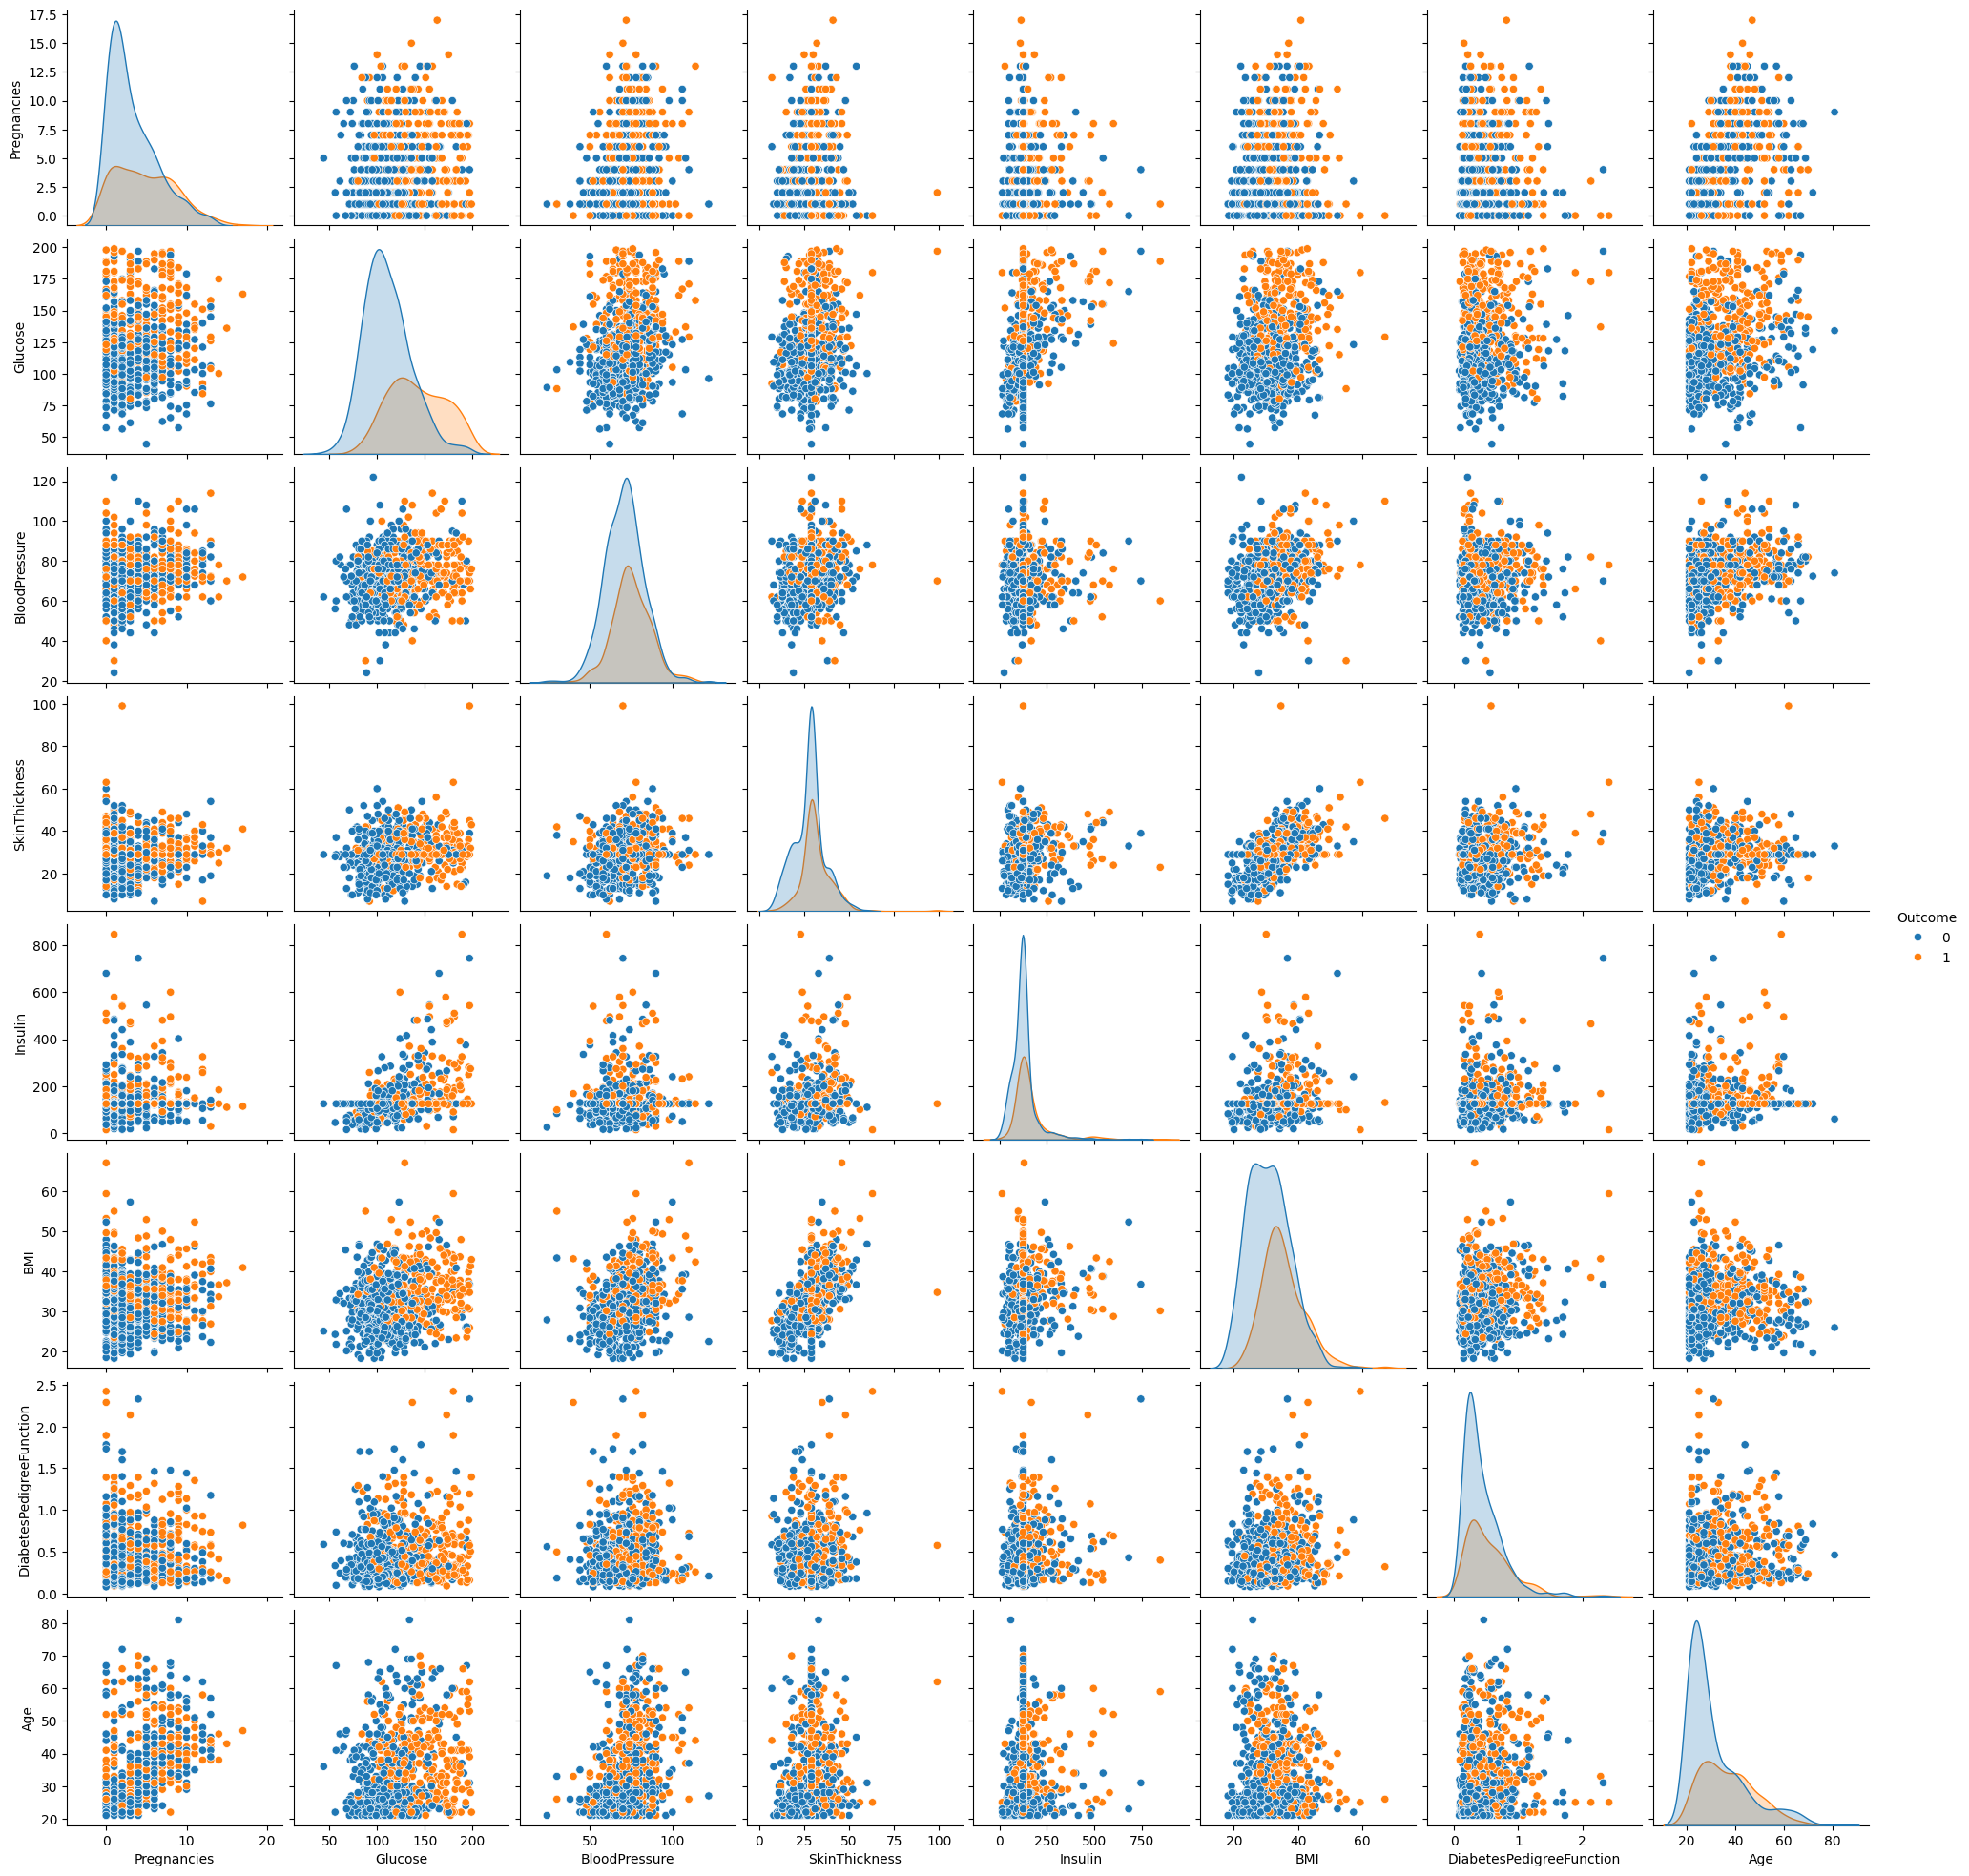

In [20]:
sns.pairplot(df, hue='Outcome')
plt.show()

- The pair plot was used to see relationships between features and the diabetes outcome. The two outcome classes overlap in many areas, but higher glucose values show a clearer tendency toward the diabetic class.

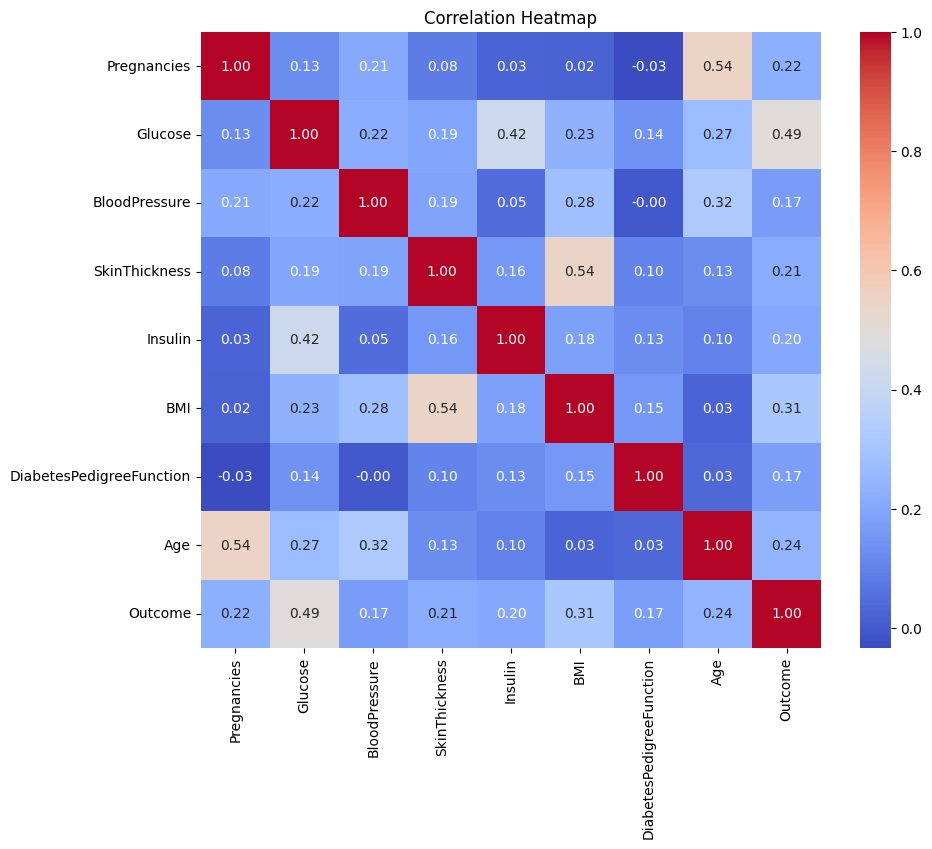

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

### 3. Model Building:

- a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).

In [22]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

- b. Train the model using the training data.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,train_size=0.8,random_state=42)

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [25]:
model = LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [26]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
      dtype=int64)

### 4. Model Evaluation:

- a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.

In [27]:
acc= accuracy_score(y_test,y_pred)
print("Accuracy: ",acc)

Accuracy:  0.7662337662337663


In [28]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82        99
           1       0.69      0.62      0.65        55

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154



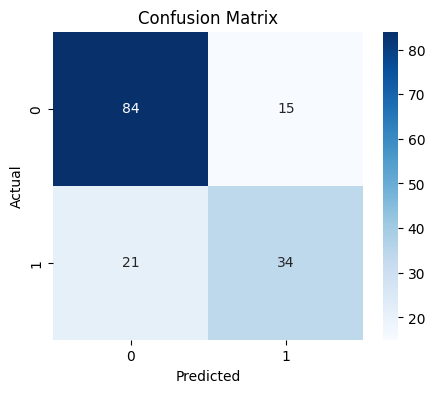

In [29]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

- The model correctly identified 84 non-diabetic and 34 diabetic patients. It incorrectly classified 15 non-diabetic patients as diabetic and missed 21 diabetic patients by predicting them as non-diabetic.

In [30]:
print("Precision :", precision_score(y_test,y_pred))
print("Recall :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))

Precision : 0.6938775510204082
Recall : 0.6181818181818182
F1 Score : 0.6538461538461539


- Precision tells us how many of the patients predicted as diabetic were actually diabetic. In this model, about 69% of the positive predictions were correct.
- Recall tells us how many of the actual diabetic patients were correctly identified. The model identified about 62% of the diabetic patients.
- The F1-score combines precision and recall into one value. A score of about 65% shows that the model has a moderate balance between identifying diabetic patients and avoiding incorrect positive predictions.

### Visualize the ROC curve.

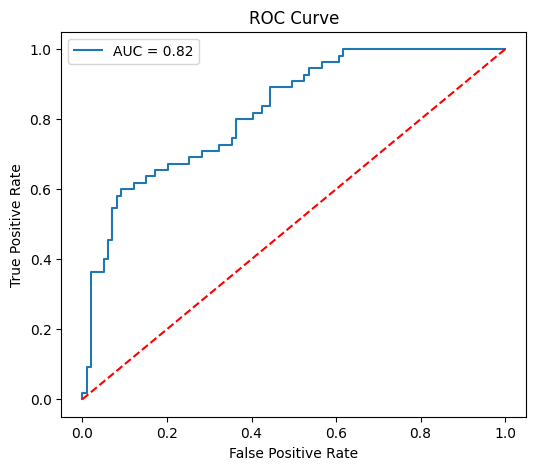

ROC-AUC Score: 0.8238751147842056


In [38]:
from sklearn.metrics import roc_curve

y_prob = model.predict_proba(X_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
auc = roc_auc_score(y_test,y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label='AUC = %.2f'%auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print("ROC-AUC Score:",auc)

- The ROC-AUC score of approximately 0.82 indicates that the model has a good ability to distinguish between diabetic and non-diabetic patients.

### 5. Interpretation:
- a. Interpret the coefficients of the logistic regression model.
- b. Discuss the significance of features in predicting the target variable (survival probability in this case).

In [32]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
1,Glucose,1.103772
5,BMI,0.687977
7,Age,0.391957
0,Pregnancies,0.222972
6,DiabetesPedigreeFunction,0.203834
3,SkinThickness,0.068535
4,Insulin,-0.138047
2,BloodPressure,-0.149709


- A positive coefficient means that an increase in the feature is associated with a higher predicted probability of diabetes, while a negative coefficient indicates the opposite, holding the other variables constant.

- Glucose has the largest positive coefficient (1.104), so it has the strongest positive influence on the model's prediction among these standardized features.

- The Logistic Regression model achieved an accuracy of 76.62% and a ROC-AUC of approximately 0.82. Glucose was the most influential positive feature, followed by BMI and Age. The model performs reasonably well overall but has difficulty identifying some diabetic patients, as shown by the 61.82% recall for the diabetic class.

### 6. Deployment with Streamlit:
- In this task, you will deploy your logistic regression model using Streamlit. The deployment can be done locally or online via Streamlit Share. Your task includes creating a Streamlit app in Python that involves loading your trained model and setting up user inputs for predictions. 

In [33]:
import pickle
pickle.dump(model, open("logistic_model.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))